<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn10catdogpred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 이전 실습에서 만들어진 모델로 새로운 개/고양이 이미지 분류 예측
# 새로운 이미지도 크기 조정 (150, 150) + 스케일링

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

MODEL_PATH = 'catdog_best.keras'
IMG_HEIGHT, IMG_WIDTH = 150, 150  # 학습에 사용한 크기와 동일
THRESH  = 0.5 # 시그모이드 임계값 조정 가능(04~0.6)

ids_to_name = {0: 'cat', 1: 'dog'}

# model
model = tf.keras.models.load_model(MODEL_PATH)
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,924,325 (121.78 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,282,884 (81.19 MB)

None


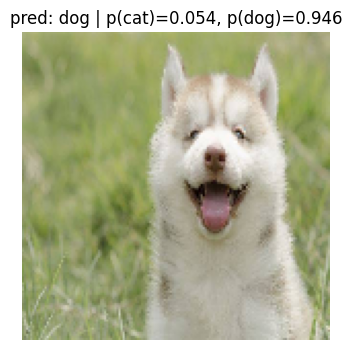

{'path': 'myimage.jpeg', 'pred': 'dog', 'prob_cat': 0.053880155086517334, 'prob_dog': 0.9461198449134827}


In [ ]:
# 전처리 함수
def preprocess_imageFunc(image_path):
  img = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
  arr = tf.keras.preprocessing.image.img_to_array(img)
  arr = arr / 255.0
  arr = np.expand_dims(arr, axis=0)   # 배치 차원 추가 -> (1,H.W,C)
  return arr

# 단일 이미지 예측 함수
def predict_oneFunc(img_path, show=True):
  x = preprocess_imageFunc(img_path)
  # print(x)
  prob_dog = float(model.predict(x, verbose=0)[0][0]) # 시그모이드 출력
  pred_idx = int(prob_dog > THRESH)
  pred_name = ids_to_name[pred_idx]
  prob_cat = 1.0 - prob_dog # cat 확률

  if show:
    img_disp = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    plt.figure(figsize=(4,4))
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(f'pred: {pred_name} | p(cat)={prob_cat:.3f}, p(dog)={prob_dog:.3f}')
    plt.show()

  return {'path':img_path, 'pred':pred_name, 'prob_cat':prob_cat, 'prob_dog':prob_dog}

res = predict_oneFunc('myimage.jpeg', show=True)
print(res)